# Week 4 — 데이터 품질 진단

소수몽키 YouTube transcript 5건을 대상으로 chunking 전략을 정하기 전 데이터 특성을 점검한다.

- 구조적 특성 (구두점 패턴, 머리/꼬리, 노이즈)
- 길이 분포 (문자, tiktoken 토큰)
- 진단 결론 한 단락 (`docs/week4_retrospective.md` §2에 옮김)

In [1]:
from naive_rag.constants import WEEK4_CONTENT_IDS
from naive_rag.loader import load_transcripts

docs = load_transcripts(content_ids=WEEK4_CONTENT_IDS)
print(f"로드된 문서: {len(docs)}건")
for d in docs:
    print(f"  {d.metadata['published_at']} | {d.metadata['title']}  (len={len(d.page_content)})")

로드된 문서: 5건
  2026-04-28 00:00:00 | 빅테크 생존을 건 AI 투자 시작됐다,양보없는 전쟁의 수혜주들  (len=11979)
  2026-04-27 00:00:00 | AI에이전트가 반도체 판도 다 뒤집는다?새로운 주도주 탄생의 신호일까  (len=12904)
  2025-11-03 00:00:00 | 젠슨황의 깐부회동과 트럼프 순방이 끌어올린 증시, 주목받을 수혜주들  (len=12766)
  2025-10-04 00:00:00 | 미 증시 본격 버블은 아직 시작도 안했다? 2026 버블 시나리오(풀버전)  (len=27842)
  2025-08-05 00:00:00 | 역대급 폭락 쇼크 맞은 미국 초우량주들, 서학개미들의 줍줍 성공할까  (len=12278)


In [2]:
import tiktoken
import pandas as pd

enc = tiktoken.get_encoding("cl100k_base")

records = []
for d in docs:
    records.append({
        "title": d.metadata["title"][:30],
        "char_len": len(d.page_content),
        "token_len": len(enc.encode(d.page_content)),
    })

df = pd.DataFrame(records)
df["char_per_token"] = df["char_len"] / df["token_len"]
print(df.to_string(index=False))
print("\n전체 합:", df[["char_len", "token_len"]].sum().to_dict())
print("평균:", df[["char_len", "token_len"]].mean().round(1).to_dict())
print("min/max:", df[["char_len", "token_len"]].agg(["min", "max"]).to_dict())

                         title  char_len  token_len  char_per_token
빅테크 생존을 건 AI 투자 시작됐다,양보없는 전쟁의      11979      11874        1.008843
AI에이전트가 반도체 판도 다 뒤집는다?새로운 주도주      12904      12348        1.045028
젠슨황의 깐부회동과 트럼프 순방이 끌어올린 증시, 주목     12766      12674        1.007259
미 증시 본격 버블은 아직 시작도 안했다? 2026 버     27842      27304        1.019704
역대급 폭락 쇼크 맞은 미국 초우량주들, 서학개미들의      12278      12603        0.974212

전체 합: {'char_len': 77769, 'token_len': 76803}
평균: {'char_len': 15553.8, 'token_len': 15360.6}
min/max: {'char_len': {'min': 11979, 'max': 27842}, 'token_len': {'min': 11874, 'max': 27304}}


Matplotlib is building the font cache; this may take a moment.


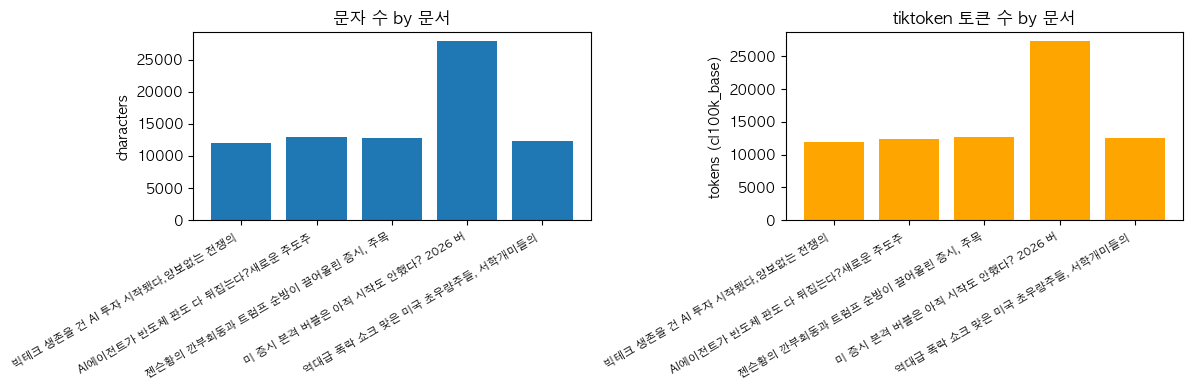

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# 한글 폰트 (macOS 기본 AppleGothic)
mpl.rcParams["font.family"] = "AppleGothic"
mpl.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(len(df)), df["char_len"])
axes[0].set_xticks(range(len(df)))
axes[0].set_xticklabels(df["title"], rotation=30, ha="right", fontsize=8)
axes[0].set_title("문자 수 by 문서")
axes[0].set_ylabel("characters")

axes[1].bar(range(len(df)), df["token_len"], color="orange")
axes[1].set_xticks(range(len(df)))
axes[1].set_xticklabels(df["title"], rotation=30, ha="right", fontsize=8)
axes[1].set_title("tiktoken 토큰 수 by 문서")
axes[1].set_ylabel("tokens (cl100k_base)")

plt.tight_layout()
plt.show()

In [4]:
import re

patterns = {
    r"\n\n": "double newline",
    r"\n": "single newline",
    r"\. ": "period+space (영어식)",
    r"다\.": "한국어 종결 '다.'",
    r"요\.": "한국어 종결 '요.'",
    r"습니다": "한국어 종결 '습니다'",
    r"네요": "한국어 종결 '네요'",
    r"!": "느낌표",
    r"\?": "물음표",
}

print(f"{'패턴':30s}{'평균':>10s}{'합':>10s}")
print("-" * 50)
for pat, label in patterns.items():
    counts = [len(re.findall(pat, d.page_content)) for d in docs]
    print(f"  {label:28s}{sum(counts)/len(counts):>8.1f}{sum(counts):>10d}")

패턴                                    평균         합
--------------------------------------------------
  double newline                   0.0         0
  single newline                   0.0         0
  period+space (영어식)             212.0      1060
  한국어 종결 '다.'                     95.8       479
  한국어 종결 '요.'                     79.8       399
  한국어 종결 '습니다'                    53.6       268
  한국어 종결 '네요'                      4.8        24
  느낌표                              0.8         4
  물음표                             23.6       118


In [5]:
# 머리/꼬리 노이즈 패턴 점검 (앞 500자, 뒤 500자)
for d in docs:
    print(f"=== {d.metadata['published_at']} | {d.metadata['title']} ===")
    print("[앞 500자]")
    print(d.page_content[:500])
    print("...")
    print("[뒤 500자]")
    print(d.page_content[-500:])
    print()

=== 2026-04-28 00:00:00 | 빅테크 생존을 건 AI 투자 시작됐다,양보없는 전쟁의 수혜주들 ===
[앞 500자]
자, 이번 주 가장 중요한 이슈 있죠? 바로 슈퍼위크입니다. 빅테크 5개가 실적 발표합니다. 그래서 가장 최근 이슈들과 함께 또 주목할 만한 빅테크와 수예주들을 같이 정리 좀 해보도록 하겠습니다. 일단 제가 봤을 때는 이번 주 실적 발표를 예상하는 것보다 그냥 잘하고 있는 기업을 같이 보는 게 중요할 것 같아요. 그래야 실적 발표 나와도 떨어지면 산다 이런 마인드로 가든지 아니면 내가 과감하게 미리 좀 사놓는다 선택을 할 수 있잖아요. 최근에 제가 올해 들어서는 계속 말씀드리는데 구글, 아마존이 열일하는 것 같습니다. 호재도 많이 몰려 있고요. 특히나 이번 주에도 중요한 발표들이 연달아 나왔는데 자, 요즘 가장 핫한 AI 기업으로는 제가 봤을 때는 엔트로픽을 빼놓을 수가 없을 것 같아요. 물론 오프닝 AI도 있지만 요즘엔 엔트로픽이 가장 핫해서 저도 거의 매주 말씀드리는 것 같은데 여기에 초기 투자를 잘 해놨던 기업이 바로 구글과 아마존이죠. 그래서 구글과 아마존이 원래 초기 투자를
...
[뒤 500자]
니다 그래서 단기 격등은 조심하셔야겠지만 분아매수나 조정으로 관심있는 주식이나 ETF정도 대응해보시면 나쁘지 않을 것 같습니다 그래서 당연히 반도체는 말할 것도 없이 너무 좋은 상황이고요 데이터 센터에 들어가는 다양한 반도체 엔비디아부터 해서 CPU 인텔 AMD ARM 메모리 반도체 맞춤형 반도체 반도체 생산하는 TSMC도 말할 것도 없고요 오죽하면 TSMC말고 글로벌 3등 4등 5등 이런 반도체 생산기지 파운드리까지도 막 오르기 시작했습니다 삼성전자도 좋고 말할 것도 없죠 이런 식으로 반도체 너무 좋기 때문에 반도체 ETF도 계속 한번 주목해볼 필요가 있겠습니다 물론 단기에 너무 뜨거웠기 때문에 제가 여기 늦김표 달았지만 반도체가 18거래를 연속 상승으로 유례없이 이렇게 길게 올린 게 처음이라고 할 정도로 너무 단기 격등했기 

## 진단 결론

5건 transcript는 Whisper 기반 plain text라 헤더/표/이미지/명시적 섹션이 없고, **`\n\n`과 `\n`이 한 번도 등장하지 않는다** — baseline `RecursiveCharacterTextSplitter`의 `separators` 중 첫 두 개가 무용지물이다. 영어식 `". "`가 평균 212회/문서로 잡히지만 대부분 외래어 약자·잘못 인식된 종결어미 잔재이고, 한국어 자연 종결어미인 `다.`/`요.`/`습니다`(평균 약 230회/문서 합)는 baseline이 의미 단위로 잡지 못한다. 결과적으로 baseline 600/100은 사실상 `". "` → 공백 → 빈 문자열 fallback 위주의 character-level 분할에 가까워, 한국어 의미 경계가 끊기는 사례가 다수 있을 것으로 추정된다. 또한 모든 영상 꼬리에 일관된 광고/CTA 패턴("특강 고정댓글", "ETF 모아주시는 것도", "캘린더 카페에 올려둘게요" 등)이 있어 noise chunk로 retrieve될 가능성이 높다. 길이는 5건 합 ~77K tokens, 평균 15.4K, 최대 27.3K(2026 버블 시나리오 풀버전)로 한 영상당 약 25 chunk(chunk_size=600 기준), 가장 긴 건 ~45 chunk.

**전략 C 채택: `RecursiveCharacterTextSplitter` + 한국어 종결어미를 우선으로 한 `separators` 보강** (`["다. ", "요. ", "습니다.", "다.", "요.", ". ", " ", ""]`). 의존성 추가 없이 baseline의 "한국어 marker 부재" 약점을 직접 해결한다. 대안으로 `kiwipiepy`(한국어 형태소 기반 문장 분리)와 `SemanticChunker`(임베딩 거리 기반)를 함께 검토했으나, baseline(A)·size 변경(B)과 **동일 클래스·동일 크기에서 `separators`만 변경**되는 비교가 변수 격리 측면에서 가장 명확하다는 점, 그리고 학습 트랙 1주 분량에 의존성 추가가 부담된다는 점에서 우선 선택했다. `kiwipiepy`/`SemanticChunker`는 5주차 retrieval 고도화에서 다시 후보로 검토 가능.